In [1]:
import numpy as np

import matplotlib.pyplot as plt

import regseq2

regseq2.viz.matplotlib_style()


In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt

# ----------------------------
# Global figure + font settings
# ----------------------------
FIG_WIDTH = 7.0
FIG_HEIGHT = 3.0

mpl.rcParams.update({
    # Figure geometry
    "figure.figsize": (FIG_WIDTH, FIG_HEIGHT),
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",

    # Fonts
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,

    # Lines / markers
    "lines.linewidth": 1.2,
    "lines.markersize": 4,

    # Axes styling
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.minor.width": 0.6,
    "ytick.minor.width": 0.6,

    # Mathtext / fonts (no external LaTeX dependency)
    #"mathtext.fontset": "stix",
    #"font.family": "STIXGeneral",
})


In [7]:
from matplotlib import font_manager
import os

# insert your own fontpath, or ignore
font_path = "/Users/tomroeschinger/Library/Fonts/Lsato-ThinItalic.ttf" 
if os.path.exists(font_path):
    font_manager.fontManager.addfont(font_path)
    prop = font_manager.FontProperties(fname=font_path)

weight = 'regular'
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Lato"],

    "font.weight": weight,        # ticks, text
    "axes.labelweight": weight,   # axis labels
    "axes.titleweight": weight,   # titles
})


In [8]:
def xlogx(p):
    return 0.0 if p <= 0.0 else p * np.log2(p)

def H_bern(p1):
    # entropy of Bernoulli with P(1)=p1
    p0 = 1.0 - p1
    return -(xlogx(p0) + xlogx(p1))

def compute_MI(h_m, h_w, p_mut):
    # P(B=1 | S=wt), P(B=1 | S=mut)
    p1_wt  = np.exp(-h_w) / (1.0 + np.exp(-h_w))
    p1_mut = np.exp(-h_m) / (1.0 + np.exp(-h_m))

    # marginal P(B=1)
    p1 = (1.0 - p_mut) * p1_wt + p_mut * p1_mut

    H_B = H_bern(p1)

    H_B_given_S = (1.0 - p_mut) * H_bern(p1_wt) + p_mut * H_bern(p1_mut)

    return H_B, H_B_given_S


Binding probability for given binding energy in two state model.

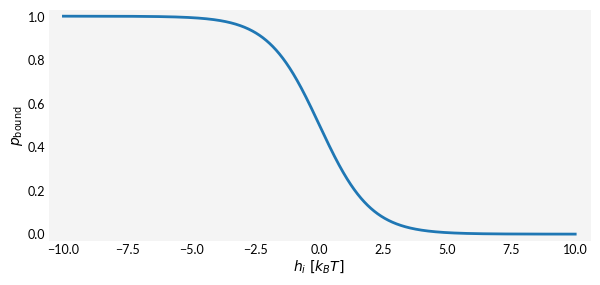

In [ ]:
fig, ax = plt.subplots(figsize=(FIG_WIDTH, 3))

x = np.arange(-10, 10, step=0.01)
y = np.exp(-x) / (1 + np.exp(-x))
ax.plot(x, y, lw=2)
ax.set_ylabel(r'$p_\mathrm{bound}$')
ax.set_xlabel(r'$h_i\ [k_BT]$')
fig.savefig('../figures/toy_binding_curve.pdf')


Entropy, conditional entropy and mutual information.

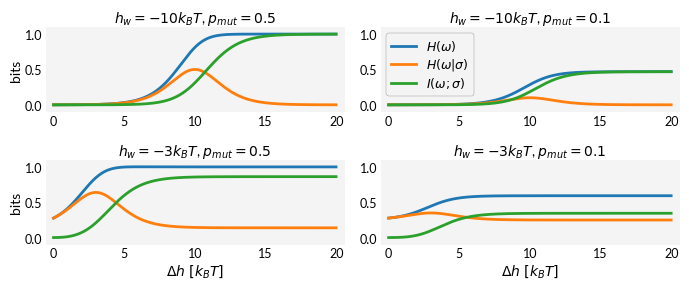

In [ ]:
fig, ax = plt.subplots(2, 2)
p_mut = 0.5
x = np.arange(0, 20, step=0.01)


h_w = -10
y = np.array([compute_MI(h_w=h_w, h_m=t+h_w, p_mut=p_mut)[0] for t in x])
y1 = np.array([compute_MI(h_w=h_w, h_m=t+h_w, p_mut=p_mut)[1] for t in x])



ax[0, 0].plot(x, y, lw=2)
ax[0, 0].plot(x, y1, lw=2)
ax[0, 0].plot(x, y-y1, lw=2)
ax[0, 0].set_ylabel("bits")
ax[0, 0].set_ylim(-0.1, 1.1)
ax[0, 0].set_title(r'$h_w=-10k_BT$, $p_{mut}=0.5$')

h_w = -3
y = np.array([compute_MI(h_w=h_w, h_m=t+h_w, p_mut=p_mut)[0] for t in x])
y1 = np.array([compute_MI(h_w=h_w, h_m=t+h_w, p_mut=p_mut)[1] for t in x])


ax[1, 0].plot(x, y, lw=2)
ax[1, 0].plot(x, y1, lw=2)
ax[1, 0].plot(x, y-y1, lw=2)
ax[1, 0].set_ylim(-0.1, 1.1)
ax[1, 0].set_xlabel(r'$\Delta h\ [k_BT]$')
ax[1, 0].set_ylabel("bits")
ax[1, 0].set_title(r'$h_w=-3k_BT$, $p_{mut}=0.5$')


p_mut = 0.1
h_w = -10
y = np.array([compute_MI(h_w=h_w, h_m=t+h_w, p_mut=p_mut)[0] for t in x])
y1 = np.array([compute_MI(h_w=h_w, h_m=t+h_w, p_mut=p_mut)[1] for t in x])



ax[0, 1].plot(x, y, lw=2, label=r"$H(\omega)$")
ax[0, 1].plot(x, y1, lw=2, label=r"$H(\omega|\sigma)$")
ax[0, 1].plot(x, y-y1, lw=2, label=r"$I(\omega;\sigma)$")
ax[0, 1].set_ylim(-0.1, 1.1)
ax[0, 1].legend()
ax[0, 1].set_title(r'$h_w=-10k_BT$, $p_{mut}=0.1$')

h_w = -3
y = np.array([compute_MI(h_w=h_w, h_m=t+h_w, p_mut=p_mut)[0] for t in x])
y1 = np.array([compute_MI(h_w=h_w, h_m=t+h_w, p_mut=p_mut)[1] for t in x])


ax[1, 1].plot(x, y, lw=2)
ax[1, 1].plot(x, y1, lw=2)
ax[1, 1].plot(x, y-y1, lw=2)
ax[1, 1].set_ylim(-0.1, 1.1)
ax[1, 1].set_xlabel(r'$\Delta h\ [k_BT]$')
ax[1, 1].set_title(r'$h_w=-3k_BT$, $p_{mut}=0.1$')
plt.tight_layout()

fig.savefig('../figures/MI_toy_example.pdf')



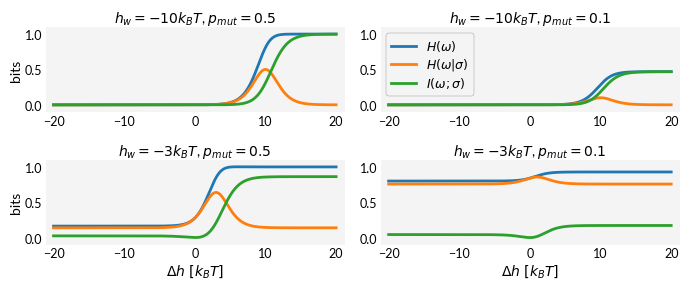

In [ ]:
fig, ax = plt.subplots(2, 2)
p_mut = 0.5
x = np.arange(-20, 20, step=0.01)


h_w = -10
y = np.array([compute_MI(h_w=h_w, h_m=t+h_w, p_mut=p_mut)[0] for t in x])
y1 = np.array([compute_MI(h_w=h_w, h_m=t+h_w, p_mut=p_mut)[1] for t in x])



ax[0, 0].plot(x, y, lw=2)
ax[0, 0].plot(x, y1, lw=2)
ax[0, 0].plot(x, y-y1, lw=2)
ax[0, 0].set_ylabel("bits")
ax[0, 0].set_ylim(-0.1, 1.1)
ax[0, 0].set_title(r'$h_w=-10k_BT$, $p_{mut}=0.5$')

h_w = -3
y = np.array([compute_MI(h_w=h_w, h_m=t+h_w, p_mut=p_mut)[0] for t in x])
y1 = np.array([compute_MI(h_w=h_w, h_m=t+h_w, p_mut=p_mut)[1] for t in x])


ax[1, 0].plot(x, y, lw=2)
ax[1, 0].plot(x, y1, lw=2)
ax[1, 0].plot(x, y-y1, lw=2)
ax[1, 0].set_ylim(-0.1, 1.1)
ax[1, 0].set_xlabel(r'$\Delta h\ [k_BT]$')
ax[1, 0].set_ylabel("bits")
ax[1, 0].set_title(r'$h_w=-3k_BT$, $p_{mut}=0.5$')


p_mut = 0.1
h_w = -10
y = np.array([compute_MI(h_w=h_w, h_m=t+h_w, p_mut=p_mut)[0] for t in x])
y1 = np.array([compute_MI(h_w=h_w, h_m=t+h_w, p_mut=p_mut)[1] for t in x])



ax[0, 1].plot(x, y, lw=2, label=r"$H(\omega)$")
ax[0, 1].plot(x, y1, lw=2, label=r"$H(\omega|\sigma)$")
ax[0, 1].plot(x, y-y1, lw=2, label=r"$I(\omega;\sigma)$")
ax[0, 1].set_ylim(-0.1, 1.1)
ax[0, 1].legend()
ax[0, 1].set_title(r'$h_w=-10k_BT$, $p_{mut}=0.1$')

h_w = -1
y = np.array([compute_MI(h_w=h_w, h_m=t+h_w, p_mut=p_mut)[0] for t in x])
y1 = np.array([compute_MI(h_w=h_w, h_m=t+h_w, p_mut=p_mut)[1] for t in x])


ax[1, 1].plot(x, y, lw=2)
ax[1, 1].plot(x, y1, lw=2)
ax[1, 1].plot(x, y-y1, lw=2)
ax[1, 1].set_ylim(-0.1, 1.1)
ax[1, 1].set_xlabel(r'$\Delta h\ [k_BT]$')
ax[1, 1].set_title(r'$h_w=-3k_BT$, $p_{mut}=0.1$')
plt.tight_layout()

fig.savefig('../figures/MI_toy_example.pdf')



In [ ]:
compute_MI(h_w=h_w, h_m=0+h_w, p_mut=p_mut)

(np.float64(0.8399415379831693), np.float64(0.8399415379831694))

In [ ]:
y

array([0.79842829, 0.79842829, 0.79842829, ..., 0.92676435, 0.92676435,
       0.92676435], shape=(4000,))

In [ ]:
y1

array([0.75594739, 0.75594739, 0.75594739, ..., 0.7559474 , 0.7559474 ,
       0.7559474 ], shape=(4000,))

In [ ]:
import numpy as np
from math import lgamma


def log_binom_pmf(k: int, n: int, p: float) -> float:
    """
    log P(X=k) for X ~ Binomial(n,p), computed stably using lgamma.
    Works for 0<p<1. For p=0 or 1, handle separately.
    """
    if p <= 0.0:
        return 0.0 if k == 0 else -np.inf
    if p >= 1.0:
        return 0.0 if k == n else -np.inf

    # log(n choose k) via log-gamma
    logC = lgamma(n + 1) - lgamma(k + 1) - lgamma(n - k + 1)
    return logC + k * np.log(p) + (n - k) * np.log(1.0 - p)

def entropy_binomial(n: int, p: float, base: float = 2.0) -> float:
    """
    Entropy H(Binomial(n,p)) in bits if base=2, in nats if base=np.e.
    """
    logs = np.array([log_binom_pmf(k, n, p) for k in range(n + 1)], dtype=float)
    probs = np.exp(logs)  # safe because n is small; probs sum ~ 1
    # Compute -sum p log p, converting log base
    H_nats = -np.sum(probs * logs, where=np.isfinite(logs))
    return H_nats / np.log(base)

def delta_entropy(n: int, p: float, base: float = 2.0) -> float:
    """
    ΔH_n(p) = H(Binomial(n,p)) - H(Binomial(n-1,p))
    """
    if n < 1:
        raise ValueError("n must be >= 1")
    return entropy_binomial(n, p, base=base) - entropy_binomial(n - 1, p, base=base)

# Example usage:
# N = 10; p = 0.1
# print(entropy_binomial(10, 0.1), delta_entropy(10, 0.1))


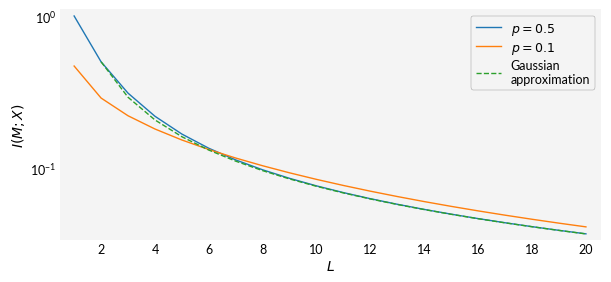

In [ ]:
x = np.arange(1, 21)

fig, ax = plt.subplots(figsize=(FIG_WIDTH, 3))

pmut = 0.5
y = [delta_entropy(n=t, p=pmut) for t in x]
y1 = [1/2 * np.log2(t/(t-1)) for t in x[1:]]
ax.plot(x, y, lw=1, label=r"$p=0.5$")

pmut = 0.1
y = [delta_entropy(n=t, p=pmut) for t in x]
ax.plot(x, y, lw=1, label=r"$p=0.1$")
ax.plot(x[1:], y1, lw=1, ls='--', label="Gaussian\napproximation")

ax.legend()
ax.set_yscale('log')
ax.set_xticks(np.arange(2, 21, step=2))
ax.set_xlabel(r"$L$")
ax.set_ylabel(r'$I(M; X)$')
fig.savefig('../figures/coinflip_MI.pdf')


In [ ]:
delta_entropy(n=20, p=0.1)

np.float64(0.041157938883654044)

In [ ]:
delta_entropy(n=10, p=0.1)

np.float64(0.08440412670538477)

FileNotFoundError: [Errno 2] No such file or directory: '../figures/bins_noise_MI.pdf'

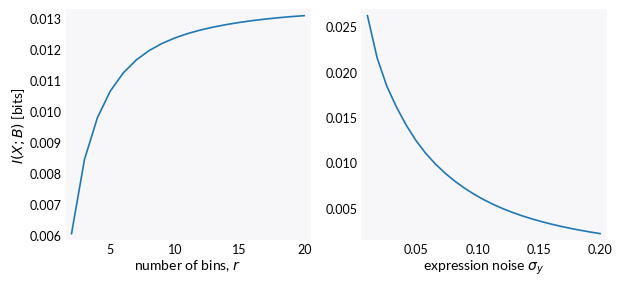

In [ ]:
#!/usr/bin/env python3
"""
Compute mutual information I(B;X) when:
X -> M -> Y -> Y' -> μ -> B

- X ∈ {0,1}: whether a focal base is mutated.
- M: total # mutations in a binding site of length L.
  * If X=0: M ~ Binomial(L-1, p_mut)
  * If X=1: M = 1 + Binomial(L-1, p_mut)
- Y(m): "true" expression (user-specified function).
- Y' | M=m ~ Normal(mean=Y(m), sd=sigma_Y)  (biological noise)
- μ = max(Y', Y_min)  (detection limit on realized expression)
- B: discretization/binning of μ into r bins.

This script computes I(B;X) for:
  (a) fixed sigma_Y, varying #bins r
  (b) fixed r, varying sigma_Y

No plotting is done; you can plot returned arrays.

Compatible with macOS; depends on numpy and scipy.
"""

from __future__ import annotations

from dataclasses import dataclass
from typing import Callable, Iterable, Literal, Tuple, Dict, Optional

import numpy as np
from scipy.stats import norm


# ----------------------------
# Core model pieces
# ----------------------------

def y_logistic(
    m: np.ndarray,
    G_w: float,
    delta_h: float,
    beta: float = 1.0,
    scale: float = 1.0,
) -> np.ndarray:
    """
    Example Y(m) matching your earlier form:
        Y(m) ∝ 1 / (1 + exp(beta*(G_w + m*delta_h)))
    Returns Y(m) in the same units as 'scale'.

    Notes:
    - If you have a different Y(m), pass your own function into MI routines.
    """
    z = beta * (G_w + m * delta_h)
    return scale / (1.0 + np.exp(z))


def binomial_pmf(n: int, p: float) -> np.ndarray:
    """
    Stable Binomial(n,p) PMF for k=0..n using logs (no scipy.special required).
    """
    # log C(n,k) via gammaln
    from scipy.special import gammaln
    k = np.arange(n + 1)
    logC = gammaln(n + 1) - gammaln(k + 1) - gammaln(n - k + 1)

    # handle p=0 or p=1 explicitly to avoid nan
    if p == 0.0:
        pmf = np.zeros(n + 1)
        pmf[0] = 1.0
        return pmf
    if p == 1.0:
        pmf = np.zeros(n + 1)
        pmf[n] = 1.0
        return pmf

    logp = np.log(p)
    logq = np.log(1.0 - p)
    logpmf = logC + k * logp + (n - k) * logq
    pmf = np.exp(logpmf)
    pmf /= pmf.sum()  # guard tiny drift
    return pmf


def pmf_M_given_X(L: int, p_mut: float) -> Tuple[np.ndarray, np.ndarray]:
    """
    Returns:
      pmf0[m] = P(M=m | X=0) for m=0..L
      pmf1[m] = P(M=m | X=1) for m=0..L

    Where M counts total mutations in L positions, given the focal base state.
    """
    if L < 1:
        raise ValueError("L must be >= 1")

    # X=0 => M = Bin(L-1, p)
    pmf_k = binomial_pmf(L - 1, p_mut)  # k=0..L-1
    pmf0 = np.zeros(L + 1)
    pmf0[0:L] = pmf_k  # M=k

    # X=1 => M = 1 + Bin(L-1, p)
    pmf1 = np.zeros(L + 1)
    pmf1[1:L + 1] = pmf_k  # M=1+k

    # sanity
    pmf0 /= pmf0.sum()
    pmf1 /= pmf1.sum()
    return pmf0, pmf1


# ----------------------------
# Binning: edges + probabilities
# ----------------------------

def make_bin_edges(
    mode: Literal["equal_width", "quantile"],
    r: int,
    *,
    mu_min: float,
    mu_max: float,
    mu_grid: np.ndarray,
    p_mu_grid: np.ndarray,
) -> np.ndarray:
    """
    Build r bins [e0,e1), [e1,e2), ..., [e_{r-1}, e_r] with final edge inclusive.

    - equal_width: edges equally spaced from mu_min to mu_max
    - quantile: edges chosen so each bin has ~equal probability under p(mu)

    Inputs:
      mu_grid, p_mu_grid should represent a *normalized* discretized approximation
      of the marginal p(mu) on the grid.
    """
    if r < 2:
        raise ValueError("r (number of bins) must be >= 2")
    if mu_max <= mu_min:
        raise ValueError("mu_max must be > mu_min")

    if mode == "equal_width":
        edges = np.linspace(mu_min, mu_max, r + 1)
        return edges

    if mode == "quantile":
        # CDF from grid
        cdf = np.cumsum(p_mu_grid)
        cdf /= cdf[-1]
        qs = np.linspace(0.0, 1.0, r + 1)

        edges = np.interp(qs, cdf, mu_grid)
        # force exact min/max
        edges[0] = mu_min
        edges[-1] = mu_max
        # ensure strictly increasing (avoid degenerate bins if distribution is spiky)
        edges = np.maximum.accumulate(edges)
        # If duplicates remain, jitter minimally
        eps = 1e-12 * max(1.0, abs(mu_max - mu_min))
        for i in range(1, len(edges)):
            if edges[i] <= edges[i - 1]:
                edges[i] = edges[i - 1] + eps
        edges[-1] = mu_max
        return edges

    raise ValueError(f"Unknown mode={mode!r}")


def prob_bins_from_cdf(
    edges: np.ndarray,
    cdf_func: Callable[[np.ndarray], np.ndarray],
) -> np.ndarray:
    """
    Compute bin probabilities P(B=i) = CDF(e_{i+1}) - CDF(e_i),
    using a provided CDF function of μ (vectorized).
    """
    lo = edges[:-1]
    hi = edges[1:]
    p = cdf_func(hi) - cdf_func(lo)
    # numerical safety
    p = np.clip(p, 0.0, 1.0)
    p /= p.sum()  # should already sum ~1, but guard drift
    return p


# ----------------------------
# MI computation
# ----------------------------

def mutual_information_discrete(
    p_b: np.ndarray,
    p_b_given_x: np.ndarray,
    p_x: np.ndarray,
    *,
    log_base: float = 2.0,
) -> float:
    """
    Compute I(B;X) from:
      p_b[i] = P(B=i)
      p_b_given_x[x,i] = P(B=i | X=x)
      p_x[x] = P(X=x)

    Uses:
      I = sum_x p(x) * KL( p(B|x) || p(B) )
    """
    if p_b_given_x.shape[0] != p_x.shape[0]:
        raise ValueError("p_b_given_x and p_x shape mismatch")

    eps = 1e-300
    p_b_safe = np.clip(p_b, eps, 1.0)
    p_b_safe /= p_b_safe.sum()

    I = 0.0
    for x in range(p_x.shape[0]):
        px = p_x[x]
        if px <= 0:
            continue
        p = np.clip(p_b_given_x[x], eps, 1.0)
        p /= p.sum()
        I += px * np.sum(p * (np.log(p) - np.log(p_b_safe)))

    if log_base == 2.0:
        I /= np.log(2.0)
    elif log_base == np.e:
        pass
    else:
        I /= np.log(log_base)
    return float(I)


def compute_I_BX_with_noise_and_bins(
    *,
    L: int,
    p_mut: float,
    p_x1: float,
    sigma_y: float,
    y_min: float,
    y_of_m: Callable[[np.ndarray], np.ndarray],
    r_bins: int,
    binning: Literal["equal_width", "quantile"] = "equal_width",
    grid_points: int = 4001,
    grid_sigma_span: float = 6.0,
) -> Dict[str, object]:
    """
    Returns a dict containing:
      - I_bits: mutual information I(B;X) in bits
      - edges: bin edges
      - pB: P(B)
      - pB_given_X: P(B | X) shape (2, r_bins)
      - mu_grid, p_mu_grid (marginal approx) for debugging/quantile edges

    Key trick:
      We compute CDF of μ|M=m analytically for the censored-normal:
        μ = y_min if Y' < y_min else Y'
      so for t >= y_min:
        F_{μ|m}(t) = P(μ <= t) = P(Y' < y_min) + P(y_min <= Y' <= t)
                 = Φ((y_min - Y(m))/σ) + (Φ((t - Y(m))/σ) - Φ((y_min - Y(m))/σ))
                 = Φ((t - Y(m))/σ)
      and for t < y_min:
        F_{μ|m}(t) = 0
      i.e. the CDF above threshold is just the usual normal CDF.

      Then mixture over M given X gives F_{μ|X}(t),
      and mixture over X gives F_μ(t).
      Bin probabilities are differences of CDF at edges.
    """
    if sigma_y <= 0:
        raise ValueError("sigma_y must be > 0")
    if not (0.0 <= p_mut <= 1.0):
        raise ValueError("p_mut must be in [0,1]")
    if not (0.0 <= p_x1 <= 1.0):
        raise ValueError("p_x1 must be in [0,1]")
    if r_bins < 2:
        raise ValueError("r_bins must be >= 2")

    # P(X)
    p_x = np.array([1.0 - p_x1, p_x1], dtype=float)

    # P(M|X)
    pmf0, pmf1 = pmf_M_given_X(L=L, p_mut=p_mut)
    pmfMx = np.stack([pmf0, pmf1], axis=0)  # shape (2, L+1)

    # Y(m) for m=0..L
    m_vals = np.arange(L + 1, dtype=float)
    y_vals = np.asarray(y_of_m(m_vals), dtype=float)
    if y_vals.shape != (L + 1,):
        raise ValueError("y_of_m must return an array of shape (L+1,) when passed m=0..L")

    # Define CDF functions
    def cdf_mu_given_m(t: np.ndarray, mean: float) -> np.ndarray:
        """
        CDF of μ given M=m, with censoring at y_min.
        For t < y_min -> 0
        For t >= y_min -> Φ((t-mean)/sigma)
        """
        t = np.asarray(t, dtype=float)
        out = np.zeros_like(t)
        mask = t >= y_min
        out[mask] = norm.cdf((t[mask] - mean) / (sigma_y))
        return out

    def cdf_mu_given_x(t: np.ndarray, x: int) -> np.ndarray:
        """
        Mixture over m:
          F_{μ|X=x}(t) = sum_m P(m|x) F_{μ|m}(t)
        """
        t = np.asarray(t, dtype=float)
        # broadcast: (L+1, len(t))
        F = np.stack([cdf_mu_given_m(t, mean=y_vals[m]) for m in range(L + 1)], axis=0)
        return np.sum(pmfMx[x, :, None] * F, axis=0)

    def cdf_mu(t: np.ndarray) -> np.ndarray:
        """
        Mixture over X:
          F_μ(t) = sum_x P(x) F_{μ|x}(t)
        """
        t = np.asarray(t, dtype=float)
        Fx0 = cdf_mu_given_x(t, 0)
        Fx1 = cdf_mu_given_x(t, 1)
        return p_x[0] * Fx0 + p_x[1] * Fx1

    # Choose μ-grid bounds for quantile binning / diagnostics.
    # Lower bound is y_min (since μ is censored there).
    mu_min = y_min

    # Upper bound: max mean + span*sigma
    mu_max = float(np.max(y_vals) + grid_sigma_span * sigma_y)
    if mu_max <= mu_min:
        mu_max = mu_min + 1.0

    mu_grid = np.linspace(mu_min, mu_max, grid_points)

    # Approximate marginal density on grid via finite differences of CDF
    # (for quantile binning only; MI itself uses CDF differences exactly at edges).
    F_grid = cdf_mu(mu_grid)
    p_mu_grid = np.diff(F_grid, prepend=0.0)
    # Ensure nonnegative and normalize
    p_mu_grid = np.clip(p_mu_grid, 0.0, None)
    if p_mu_grid.sum() > 0:
        p_mu_grid /= p_mu_grid.sum()

    # Bin edges
    edges = make_bin_edges(
        mode=binning,
        r=r_bins,
        mu_min=mu_min,
        mu_max=mu_max,
        mu_grid=mu_grid,
        p_mu_grid=p_mu_grid,
    )

    # Bin probabilities from CDF differences
    pB = prob_bins_from_cdf(edges, cdf_mu)

    pB_given_X = np.zeros((2, r_bins), dtype=float)
    for x in (0, 1):
        pB_given_X[x] = prob_bins_from_cdf(edges, lambda t, _x=x: cdf_mu_given_x(t, _x))

    I_bits = mutual_information_discrete(pB, pB_given_X, p_x, log_base=2.0)

    return {
        "I_bits": I_bits,
        "edges": edges,
        "pB": pB,
        "pB_given_X": pB_given_X,
        "mu_grid": mu_grid,
        "p_mu_grid": p_mu_grid,
        "mu_min": mu_min,
        "mu_max": mu_max,
    }


# ----------------------------
# Sweeps: vary bins or noise
# ----------------------------

def sweep_bins_fixed_noise(
    *,
    r_list: Iterable[int],
    L: int,
    p_mut: float,
    p_x1: float,
    sigma_y: float,
    y_min: float,
    y_of_m: Callable[[np.ndarray], np.ndarray],
    binning: Literal["equal_width", "quantile"] = "equal_width",
) -> Dict[str, np.ndarray]:
    """
    Compute I(B;X) for a fixed noise sigma_y while varying number of bins.
    Returns dict with arrays: r, I_bits
    """
    r_arr = np.array(list(r_list), dtype=int)
    I_arr = np.zeros_like(r_arr, dtype=float)

    for i, r in enumerate(r_arr):
        out = compute_I_BX_with_noise_and_bins(
            L=L,
            p_mut=p_mut,
            p_x1=p_x1,
            sigma_y=sigma_y,
            y_min=y_min,
            y_of_m=y_of_m,
            r_bins=int(r),
            binning=binning,
        )
        I_arr[i] = out["I_bits"]

    return {"r": r_arr, "I_bits": I_arr}


def sweep_noise_fixed_bins(
    *,
    sigma_list: Iterable[float],
    L: int,
    p_mut: float,
    p_x1: float,
    r_bins: int,
    y_min: float,
    y_of_m: Callable[[np.ndarray], np.ndarray],
    binning: Literal["equal_width", "quantile"] = "equal_width",
) -> Dict[str, np.ndarray]:
    """
    Compute I(B;X) for a fixed number of bins while varying noise sigma_y.
    Returns dict with arrays: sigma_y, I_bits
    """
    s_arr = np.array(list(sigma_list), dtype=float)
    I_arr = np.zeros_like(s_arr, dtype=float)

    for i, s in enumerate(s_arr):
        out = compute_I_BX_with_noise_and_bins(
            L=L,
            p_mut=p_mut,
            p_x1=p_x1,
            sigma_y=float(s),
            y_min=y_min,
            y_of_m=y_of_m,
            r_bins=r_bins,
            binning=binning,
        )
        I_arr[i] = out["I_bits"]

    return {"sigma_y": s_arr, "I_bits": I_arr}


# ----------------------------
# Example usage (delete if you want)
# ----------------------------

# --- Parameters you likely want to set ---
L = 20
p_mut = 0.1
p_x1 = p_mut  # often you set P(X=1)=p_mut for symmetry with mutation rate
sigma_y = 0.05
y_min = 0.3

# Use the logistic Y(m) as an example.
# Replace with your thesis-specific Y(m).
def my_Y(m: np.ndarray) -> np.ndarray:
    return y_logistic(m, G_w=-6.0, delta_h=1, beta=1.0, scale=1.0)

# (A) fixed noise, vary bins
r_list = range(2, 21)  # 2..50 bins
out_bins = sweep_bins_fixed_noise(
    r_list=r_list,
    L=L,
    p_mut=p_mut,
    p_x1=p_x1,
    sigma_y=sigma_y,
    y_min=y_min,
    y_of_m=my_Y,
    binning="quantile",  # or "equal_width"
)


# (B) fixed bins, vary noise
sigma_list = np.linspace(0.01, 0.2, 25)
out_noise = sweep_noise_fixed_bins(
    sigma_list=sigma_list,
    L=L,
    p_mut=p_mut,
    p_x1=p_x1,
    r_bins=10,
    y_min=y_min,
    y_of_m=my_Y,
    binning="quantile",
)


fig, ax = plt.subplots(1, 2, figsize=(FIG_WIDTH, 3))
ax[0].plot(out_bins['r'], out_bins['I_bits'])
ax[1].plot(out_noise['sigma_y'], out_noise['I_bits'])

ax[0].set_xlabel(r'number of bins, $r$')
ax[0].set_ylabel(r'$I(X;B)$ [bits]')
ax[1].set_xlabel(r'expression noise $\sigma_y$')

#fig.savefig("../figures/bins_noise_MI.pdf")